## AlphaEarth vs LandTrendr — Side-by-Side Comparison (15 Sites)

**Purpose**: Compare AlphaEarth embedding-based and LandTrendr NDVI-based change detection
across 15 western U.S. study sites. Computes IoU (Intersection over Union) between both
algorithms' binary change masks.

**Inputs**:
- `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL` (AlphaEarth, 2017–2024)
- 15 pre-computed LandTrendr GEE assets (see `src/config.py`)

**Outputs**: Side-by-side map layers; IoU metrics printed per site
**GEE auth required**: Yes

**Key parameters** (see `src/config.py`):
- AE threshold: 0.15 cosine dissimilarity
- LT threshold: 170 NDVI units
- Both use Gaussian smoothing radius=2, sigma=1 + morphological cleanup

**Expected runtime**: 5–20 min (EE computation per site, server-side)

**How to run**: Execute cells top-to-bottom. Change `SITE_INDEX` variable to switch sites.
See `src/config.py` for the full list of `LANDTRENDR_ASSETS` keys.


# AlphaEarth vs LandTrendr: Change Detection Comparison (15 Sites)

This notebook compares change detection results from two methods across 15 study sites:

- LandTrendr (precomputed assets in GEE)
- AlphaEarth embeddings (computed on-the-fly per AOI from GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL)

We standardize outputs into three layers for each method and combine all sites into single mosaicked layers for easy visual comparison:

- YOD/YOC: Year of change (end-year of lowest similarity or LandTrendr YOD)
- MAG: Magnitude of change
- DUR: Duration (LandTrendr duration vs. AlphaEarth count of pair-years above threshold)

Use the layer control to toggle between methods and explore differences by site.

In [1]:
# Setup: imports and EE init
import ee, geemap
import math

print("Authenticating/initializing Earth Engine…")
try:
    ee.Initialize(project='ardent-fusion-421917')
except Exception:
    print("No active EE session found. Launching authentication flow…")
    ee.Authenticate()
    ee.Initialize(project='ardent-fusion-421917')

# Utility: rectangle from center with span in degrees
# Note: Pure server-side (no getInfo), span is degrees (~0.4 as requested)
def rect_from_center(lon, lat, span_deg=0.4):
    half = ee.Number(span_deg).divide(2)
    return ee.Geometry.Rectangle([
        ee.Number(lon).subtract(half),
        ee.Number(lat).subtract(half),
        ee.Number(lon).add(half),
        ee.Number(lat).add(half)
    ], None, False)

# AOIs for 15 sites (0.4° squares)
aois = {
    # Texas Urbanization
    'Austin_Urban_TX': rect_from_center(-97.8, 30.3, 0.4),
    'Dallas_Urban_TX': rect_from_center(-96.8, 32.8, 0.4),
    'Houston_Urban_TX': rect_from_center(-95.37, 29.76, 0.4),

    # Oregon Urbanization
    'Portland_Urban_OR': rect_from_center(-122.7, 45.5, 0.4),
    'Bend_Urban_OR': rect_from_center(-121.3, 44.05, 0.4),

    # California Urbanization
    'Sacramento_Urban_CA': rect_from_center(-121.5, 38.6, 0.4),

    # Oregon Wildfires
    'Santiam_Fire_OR_2020': rect_from_center(-122.25, 44.75, 0.4),
    'Bootleg_Fire_OR_2021': rect_from_center(-121.25, 42.55, 0.4),

    # California Wildfires
    'Camp_Fire_CA_2018': rect_from_center(-121.6, 39.73, 0.4),
    'Dixie_Fire_CA_2021': rect_from_center(-121.3, 40.0, 0.4),
    'Mosquito_Fire_CA_2022': rect_from_center(-120.7, 39.1, 0.4),

    # Oregon Logging
    'CoosBay_Forest_OR': rect_from_center(-124.0, 43.35, 0.4),
    'MtHood_Forest_OR': rect_from_center(-121.8, 45.35, 0.4),

    # California Logging
    'ShastaTrinity_Forest_CA': rect_from_center(-122.3, 40.9, 0.4),

    # Texas Logging
    'Angelina_Forest_TX': rect_from_center(-94.75, 31.3, 0.4),
}

print(f"Defined {len(aois)} AOIs.")


Authenticating/initializing Earth Engine…


Defined 15 AOIs.


In [2]:
# LandTrendr assets: reuse IDs from LandTrendr_AlphaEarth.ipynb
assets = {
    'Angelina_Forest_TX': 'users/xihanyao/LT_Angelina_Forest_TX_31_95_NDVI_2016_2024',
    'Austin_Urban_TX': 'users/xihanyao/LT_Austin_UrbanGrowth_30_98_NDVI_2016_2024',
    'Bend_Urban_OR': 'users/xihanyao/LT_Bend_UrbanExpansion_44_121_NDVI_2016_2024',
    'Bootleg_Fire_OR_2021': 'users/xihanyao/LT_Bootleg_Fire_2021_43_121_NDVI_2016_2024',
    'Camp_Fire_CA_2018': 'users/xihanyao/LT_CampFire_CA_2018_40_122_NDVI_2016_2024',
    'CoosBay_Forest_OR': 'users/xihanyao/LT_CoosBay_IndustrialForestry_43_124_NDVI_2016_2024',
    'Dallas_Urban_TX': 'users/xihanyao/LT_Dallas_TX_33_97_NDVI_2016_2024',
    'Dixie_Fire_CA_2021': 'users/xihanyao/LT_DixieFire_CA_2021_40_121_NDVI_2016_2024',
    'Houston_Urban_TX': 'users/xihanyao/LT_Houston_TX_30_95_NDVI_2016_2024',
    'MosquitoFire_CA_2022': 'users/xihanyao/LT_MosquitoFire_CA_2022_39_121_NDVI_2016_2024',
    'MtHood_Forest': 'users/xihanyao/LT_MtHood_WUI_Forestry_45_122_NDVI_2016_2024',
    'Portland_Urban_OR': 'users/xihanyao/LT_Portland_Metro_UrbanGrowth_45_123_NDVI_2016_2024',
    'Sacramento_Urban_CA': 'users/xihanyao/LT_Sacramento_UrbanEdge_39_121_NDVI_2016_2024',
    'Santiam_Fire_OR_2020': 'users/xihanyao/LT_Santiam_Fire_2020_45_122_NDVI_2016_2024',
    'ShastaTrinity_Forest': 'users/xihanyao/LT_ShastaTrinity_Timberlands_41_122_NDVI_2016_2024'
}

images_lt = {k: ee.Image(v) for k, v in assets.items()}
print(f"Loaded {len(images_lt)} LandTrendr assets.")

# Helper to find YOD/MAG/DUR band names

def _find_band(img, key):
    names = img.bandNames()
    # Convert to lowercase on server via regex filter; fallback to client list if needed
    # Simpler: getInfo once for band names; small metadata
    lst = names.getInfo() or []
    for b in lst:
        if key in b.lower():
            return b
    return None

# Build three combined LT layers across all sites
lt_yod_list = []
lt_mag_list = []
lt_dur_list = []

for name, img in images_lt.items():
    yod_b = _find_band(img, 'yod')
    mag_b = _find_band(img, 'mag')
    dur_b = _find_band(img, 'dur')
    geom = aois.get(name)
    if geom is None:
        # Some names (e.g., ShastaTrinity) strictly match; ensure all included
        geom = img.geometry()
    if yod_b:
        lt_yod_list.append(img.select(yod_b).clip(geom))
    if mag_b:
        lt_mag_list.append(img.select(mag_b).clip(geom))
    if dur_b:
        lt_dur_list.append(img.select(dur_b).clip(geom))

# Mosaic per band
lt_yod = ee.ImageCollection.fromImages(lt_yod_list).mosaic().rename('lt_yod') if lt_yod_list else None
lt_mag = ee.ImageCollection.fromImages(lt_mag_list).mosaic().rename('lt_mag') if lt_mag_list else None
lt_dur = ee.ImageCollection.fromImages(lt_dur_list).mosaic().rename('lt_dur') if lt_dur_list else None

print("LandTrendr combined layers prepared: ",
      f"YOD={lt_yod is not None}", f"MAG={lt_mag is not None}", f"DUR={lt_dur is not None}")

Loaded 15 LandTrendr assets.


LandTrendr combined layers prepared:  YOD=True MAG=True DUR=True


In [3]:
# AlphaEarth change detection across all AOIs (2017–2024)
embeddings = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
years = list(range(2017, 2025))

# Helper: normalize vector to unit L2

def _normalize(img):
    bands = img.bandNames()
    norm = img.select(bands).pow(2).reduce(ee.Reducer.sum()).sqrt().add(1e-6)
    return img.select(bands).divide(norm)

# Compute per-AOI AlphaEarth change layers and collect to combine
alpha_yod_list = []   # end-year of lowest similarity (2018..2024)
alpha_mag_list = []   # 1 - min cosine similarity
alpha_dur_list = []   # count of pair-years with dissimilarity > threshold

change_threshold = 0.15  # dissimilarity threshold for duration

for name, geom in aois.items():
    # Load yearly images for AOI
    imgs = []
    for y in years:
        img_y = (embeddings
                 .filterDate(ee.Date.fromYMD(y, 1, 1), ee.Date.fromYMD(y+1, 1, 1))
                 .filterBounds(geom)
                 .mosaic()
                 .clip(geom))
        imgs.append(img_y)

    # Normalize
    imgs_norm = [_normalize(i) for i in imgs]

    # Build cosine similarity images for consecutive pairs with end-year metadata
    cos_list = []
    for i in range(len(imgs_norm) - 1):
        imgA = ee.Image(imgs_norm[i])
        imgB = ee.Image(imgs_norm[i+1])
        cos = imgA.multiply(imgB).reduce(ee.Reducer.sum()).rename('cos')
        yr = years[i+1]
        cos_with_year = cos.addBands(ee.Image.constant(yr).rename('pair_year').toInt16())
        cos_list.append(cos_with_year)

    cos_ic = ee.ImageCollection.fromImages(cos_list)

    # Select pair with lowest cosine (highest dissimilarity)
    scored = cos_ic.map(lambda im: ee.Image(im).addBands(ee.Image(1).subtract(ee.Image(im).select('cos')).rename('score')))
    picked = scored.qualityMosaic('score')
    lowest_sim = picked.select('cos')
    yod_alpha = picked.select('pair_year').rename('alpha_yod')
    mag_alpha = ee.Image(1).subtract(lowest_sim).rename('alpha_mag')

    # Duration as count above threshold across pairs
    inv_sorted = cos_ic.sort('pair_year').map(lambda im: ee.Image(1).subtract(ee.Image(im).select('cos')).rename('inv'))
    mask_ic = inv_sorted.map(lambda im: ee.Image(im).gt(change_threshold).rename('mask').toInt16())
    dur_alpha = mask_ic.sum().toInt16().rename('alpha_dur')

    # Collect clipped layers
    alpha_yod_list.append(yod_alpha.clip(geom))
    alpha_mag_list.append(mag_alpha.clip(geom))
    alpha_dur_list.append(dur_alpha.clip(geom))

# Mosaic per layer across all AOIs
alpha_yod = ee.ImageCollection.fromImages(alpha_yod_list).mosaic() if alpha_yod_list else None
alpha_mag = ee.ImageCollection.fromImages(alpha_mag_list).mosaic() if alpha_mag_list else None
alpha_dur = ee.ImageCollection.fromImages(alpha_dur_list).mosaic() if alpha_dur_list else None

print("AlphaEarth combined layers prepared: ",
      f"YOD={alpha_yod is not None}", f"MAG={alpha_mag is not None}", f"DUR={alpha_dur is not None}")

AlphaEarth combined layers prepared:  YOD=True MAG=True DUR=True


In [4]:
from ipywidgets import HTML
from ipyleaflet import Marker, DivIcon  # <-- add this

# Map visualization: combined layers for both methods
Map = geemap.Map(center=[37.5, -98], zoom=4)
Map.add_basemap('Esri.WorldImagery')

# Combined AOIs as one outline layer
fc_aois = ee.FeatureCollection([ee.Feature(geom, {'name': name}) for name, geom in aois.items()])
aoi_outline = ee.Image().byte().paint(fc_aois, 1, 2)
Map.addLayer(aoi_outline, {'palette': ['#00ffff']}, 'AOIs (all)', True)

Map.default_style = {'cursor': 'pointer'}
_last_marker = {'m': None}

def _on_map_click(**kwargs):
    if kwargs.get('type') != 'click':
        return
    lat, lon = kwargs.get('coordinates')
    pt = ee.Geometry.Point([lon, lat])
    feat = fc_aois.filterBounds(pt).first()
    name = None
    if feat:
        try:
            name = feat.get('name').getInfo()
        except Exception:
            name = None
    # Remove previous marker
    if _last_marker['m'] is not None:
        try:
            Map.remove(_last_marker['m'])
        except Exception:
            pass
        _last_marker['m'] = None
    # Add popup marker
    text = f"<b>{name}</b>" if name else "<i>Outside AOIs</i>"
    marker = Marker(location=(lat, lon))
    marker.popup = HTML(value=text)
    Map.add(marker)
    _last_marker['m'] = marker

Map.on_interaction(_on_map_click)

# Visualization parameters
vis_yod = {'min': 2017, 'max': 2024,
           'palette': ['#2166ac','#4393c3','#92c5de','#fddbc7','#d6604d','#b2182b','#67001f']}
vis_mag_a = {'min': 0, 'max': 0.5, 'palette': ['white','#fee08b','#f46d43','#a50026']}
vis_mag_l = {'min': 0, 'max': 800, 'palette': ['white','#fee08b','#f46d43','#a50026']}
vis_dur_a = {'min': 0, 'max': 7, 'palette': ['#ffffff','#f3e5f5','#e1bee7','#ce93d8','#ba68c8','#9c27b0','#6a1b9a','#4a148c']}
vis_dur_l = {'min': 0, 'max': 7, 'palette': ['#ffffff','#f3e5f5','#e1bee7','#ce93d8','#ba68c8','#9c27b0','#6a1b9a','#4a148c']}

# Add LandTrendr layers (combined)
if lt_yod:
    Map.addLayer(lt_yod, vis_yod, 'LandTrendr: YOD (all sites)', False)
if lt_mag:
    Map.addLayer(lt_mag, vis_mag_l, 'LandTrendr: MAG (all sites)', True)
if lt_dur:
    Map.addLayer(lt_dur, vis_dur_l, 'LandTrendr: DUR (all sites)', False)

# Add AlphaEarth layers (combined)
if alpha_yod:
    Map.addLayer(alpha_yod, vis_yod, 'AlphaEarth: YOC (all sites)', False)
if alpha_mag:
    Map.addLayer(alpha_mag, vis_mag_a, 'AlphaEarth: MAG (all sites)', True)
if alpha_dur:
    Map.addLayer(alpha_dur, vis_dur_a, 'AlphaEarth: DUR (all sites)', False)

Map

Map(center=[37.5, -98], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [5]:
# ...existing code...
# Mosaic per layer across all AOIs
alpha_yod = ee.ImageCollection.fromImages(alpha_yod_list).mosaic() if alpha_yod_list else None
alpha_mag = ee.ImageCollection.fromImages(alpha_mag_list).mosaic() if alpha_mag_list else None
alpha_dur = ee.ImageCollection.fromImages(alpha_dur_list).mosaic() if alpha_dur_list else None

print("AlphaEarth combined layers prepared: ",
      f"YOD={alpha_yod is not None}", f"MAG={alpha_mag is not None}", f"DUR={alpha_dur is not None}")
# ...existing code...

# ==== Change-only masks (smooth then threshold) for LT and AlphaEarth ====
# Config: tweak these thresholds as needed
lt_mag_threshold = 170        # LandTrendr |MAG| threshold (after smoothing)
alpha_mag_threshold = 0.15    # AlphaEarth MAG threshold (after smoothing)

gauss_kernel = ee.Kernel.gaussian(radius=2, sigma=1, units='pixels')

# LandTrendr smoothing + mask
lt_mag_smoothed = lt_mag.convolve(gauss_kernel) if lt_mag else None
lt_change_mask = lt_mag_smoothed.abs().gt(lt_mag_threshold) if lt_mag_smoothed else None

lt_yod_masked = lt_yod.updateMask(lt_change_mask) if (lt_yod and lt_change_mask) else None
lt_mag_masked = lt_mag_smoothed.updateMask(lt_change_mask) if (lt_mag_smoothed and lt_change_mask) else None
lt_dur_masked = lt_dur.updateMask(lt_change_mask) if (lt_dur and lt_change_mask) else None

# AlphaEarth smoothing + mask
alpha_mag_smoothed = alpha_mag.convolve(gauss_kernel) if alpha_mag else None
alpha_change_mask = alpha_mag_smoothed.gt(alpha_mag_threshold) if alpha_mag_smoothed else None

alpha_yod_masked = alpha_yod.updateMask(alpha_change_mask) if (alpha_yod and alpha_change_mask) else None
alpha_mag_masked = alpha_mag_smoothed.updateMask(alpha_change_mask) if (alpha_mag_smoothed and alpha_change_mask) else None
alpha_dur_masked = alpha_dur.updateMask(alpha_change_mask) if (alpha_dur and alpha_change_mask) else None

print("Applied smoothing and change-only masks:",
      f"LT mask={'ok' if lt_change_mask else 'none'};",
      f"Alpha mask={'ok' if alpha_change_mask else 'none'}")

AlphaEarth combined layers prepared:  YOD=True MAG=True DUR=True
Applied smoothing and change-only masks: LT mask=ok; Alpha mask=ok


In [6]:
from ipywidgets import HTML
from ipyleaflet import Marker, DivIcon

# Map visualization: masked layers for both methods
Map_Masked = geemap.Map(center=[37.5, -98], zoom=4)
Map_Masked.add_basemap('Esri.WorldImagery')

# Combined AOIs as one outline layer
fc_aois = ee.FeatureCollection([ee.Feature(geom, {'name': name}) for name, geom in aois.items()])
aoi_outline = ee.Image().byte().paint(fc_aois, 1, 2)
Map_Masked.addLayer(aoi_outline, {'palette': ['#00ffff']}, 'AOIs (all)', True)

Map_Masked.default_style = {'cursor': 'pointer'}
_last_marker = {'m': None}

def _on_map_click_masked(**kwargs):
    if kwargs.get('type') != 'click':
        return
    lat, lon = kwargs.get('coordinates')
    pt = ee.Geometry.Point([lon, lat])
    feat = fc_aois.filterBounds(pt).first()
    name = None
    if feat:
        try:
            name = feat.get('name').getInfo()
        except Exception:
            name = None
    # Remove previous marker
    if _last_marker['m'] is not None:
        try:
            Map_Masked.remove(_last_marker['m'])
        except Exception:
            pass
        _last_marker['m'] = None
    # Add popup marker
    text = f"<b>{name}</b>" if name else "<i>Outside AOIs</i>"
    marker = Marker(location=(lat, lon))
    marker.popup = HTML(value=text)
    Map_Masked.add(marker)
    _last_marker['m'] = marker

Map_Masked.on_interaction(_on_map_click_masked)

# Visualization parameters (same style)
vis_yod = {'min': 2017, 'max': 2024,
           'palette': ['#2166ac','#4393c3','#92c5de','#fddbc7','#d6604d','#b2182b','#67001f']}
vis_mag_a = {'min': 0, 'max': 0.5, 'palette': ['white','#fee08b','#f46d43','#a50026']}
vis_mag_l = {'min': 0, 'max': 800, 'palette': ['white','#fee08b','#f46d43','#a50026']}
vis_dur_a = {'min': 0, 'max': 7, 'palette': ['#ffffff','#f3e5f5','#e1bee7','#ce93d8','#ba68c8','#9c27b0','#6a1b9a','#4a148c']}
vis_dur_l = {'min': 0, 'max': 7, 'palette': ['#ffffff','#f3e5f5','#e1bee7','#ce93d8','#ba68c8','#9c27b0','#6a1b9a','#4a148c']}

# Add LandTrendr layers (masked)
if lt_yod_masked:
    Map_Masked.addLayer(lt_yod_masked, vis_yod, 'LandTrendr: YOD (masked)', False)
if lt_mag_masked:
    Map_Masked.addLayer(lt_mag_masked, vis_mag_l, 'LandTrendr: MAG (smoothed+masked)', True)
if lt_dur_masked:
    Map_Masked.addLayer(lt_dur_masked, vis_dur_l, 'LandTrendr: DUR (masked)', False)

# Add AlphaEarth layers (masked)
if alpha_yod_masked:
    Map_Masked.addLayer(alpha_yod_masked, vis_yod, 'AlphaEarth: YOC (masked)', False)
if alpha_mag_masked:
    Map_Masked.addLayer(alpha_mag_masked, vis_mag_a, 'AlphaEarth: MAG (smoothed+masked)', True)
if alpha_dur_masked:
    Map_Masked.addLayer(alpha_dur_masked, vis_dur_a, 'AlphaEarth: DUR (masked)', False)

Map_Masked

Map(center=[37.5, -98], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

IoU results:
  Santiam_Fire_OR_2020                      IoU = 0.787
  CoosBay_Forest_OR                         IoU = 0.764
  Mosquito_Fire_CA_2022                     IoU = 0.712
  Bootleg_Fire_OR_2021                      IoU = 0.675
  ShastaTrinity_Forest_CA                   IoU = 0.639
  Camp_Fire_CA_2018                         IoU = 0.630
  Dixie_Fire_CA_2021                        IoU = 0.612
  MtHood_Forest_OR                          IoU = 0.599
  Angelina_Forest_TX                        IoU = 0.597
  Sacramento_Urban_CA                       IoU = 0.532
  Houston_Urban_TX                          IoU = 0.479
  Austin_Urban_TX                           IoU = 0.443
  Dallas_Urban_TX                           IoU = 0.419
  Portland_Urban_OR                         IoU = 0.396
  Bend_Urban_OR                             IoU = 0.288


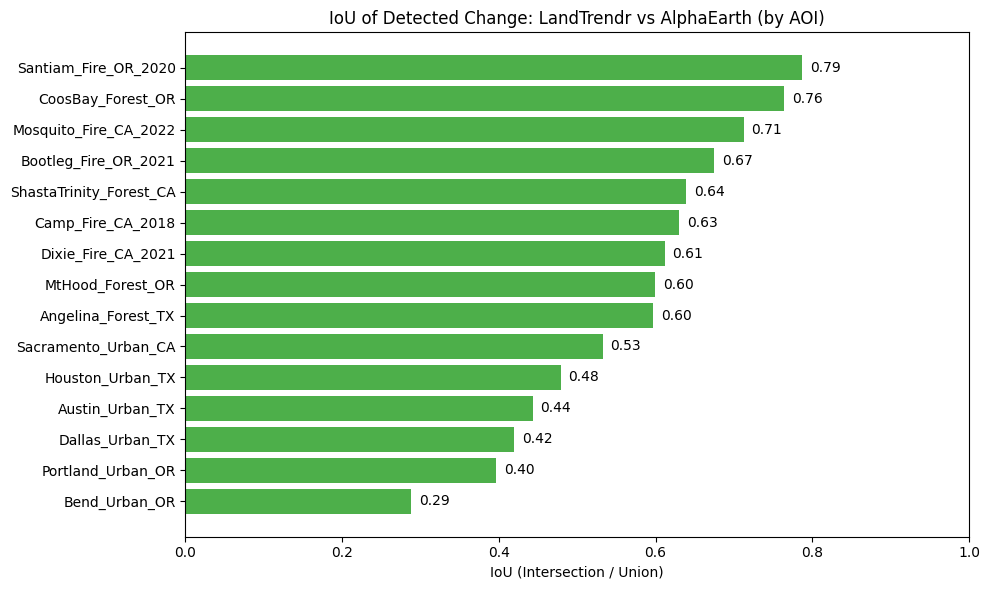

Plot saved to images/IoU_LandTrendr_AlphaEarth_15sites.png


In [7]:
# IoU per AOI between LandTrendr and AlphaEarth change masks
import ee
import matplotlib.pyplot as plt

# Require masks
if "lt_change_mask" not in globals() or lt_change_mask is None:
    raise ValueError("lt_change_mask not found. Run the smoothing+mask cell first.")
if "alpha_change_mask" not in globals() or alpha_change_mask is None:
    raise ValueError("alpha_change_mask not found. Run the smoothing+mask cell first.")

scale   = 30    # meters (align with LandTrendr/Landsat)
max_px  = 1e13

# Pre-build intersection / union images once
inter_img = lt_change_mask.And(alpha_change_mask)
union_img  = lt_change_mask.Or(alpha_change_mask)
area_img   = ee.Image.pixelArea()           # band: 'area'

# ── Batched server-side computation ────────────────────────────────────────────
# Build a FeatureCollection so EE can parallelise all 15 sites in ONE round-trip.
fc_aois_ee = ee.FeatureCollection([
    ee.Feature(geom, {"name": name}) for name, geom in aois.items()
])

def _compute_iou(feature):
    geom = feature.geometry()
    inter_area = area_img.updateMask(inter_img).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=scale, maxPixels=max_px
    ).getNumber("area")
    union_area = area_img.updateMask(union_img).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=scale, maxPixels=max_px
    ).getNumber("area")
    iou = inter_area.divide(union_area.max(1e-10))
    return feature.set({"inter": inter_area, "union": union_area, "iou": iou})

result_fc   = fc_aois_ee.map(_compute_iou)

# Single getInfo() — all 15 sites fetched in one EE request
props = result_fc.aggregate_array("iou").getInfo()
names = result_fc.aggregate_array("name").getInfo()
inter_areas = result_fc.aggregate_array("inter").getInfo()
union_areas = result_fc.aggregate_array("union").getInfo()

# Replace Nones with 0 and compute final lists
ious  = [float(v) if v is not None else 0.0 for v in props]

# Sort by IoU descending
order        = sorted(range(len(names)), key=lambda i: ious[i], reverse=True)
names_sorted = [names[i]  for i in order]
ious_sorted  = [ious[i]   for i in order]

print("IoU results:")
for n, v in zip(names_sorted, ious_sorted):
    print(f"  {n:40s}  IoU = {v:.3f}")

plt.figure(figsize=(10, 6))
bars = plt.barh(names_sorted, ious_sorted, color="#4daf4a")
plt.gca().invert_yaxis()
plt.xlim(0, 1)
plt.xlabel("IoU (Intersection / Union)")
plt.title("IoU of Detected Change: LandTrendr vs AlphaEarth (by AOI)")
for b, v in zip(bars, ious_sorted):
    plt.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center")
plt.tight_layout()
plt.savefig("../images/IoU_LandTrendr_AlphaEarth_15sites.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to images/IoU_LandTrendr_AlphaEarth_15sites.png")
